<div style='background:#004787;padding:28px 32px;border-radius:10px;margin-bottom:8px'>
<span style='color:#C8D8EA;font-size:13px;letter-spacing:2px;text-transform:uppercase'>Análisis y Síntesis de Señales Musicales · Sesión 02</span><br>
<span style='color:white;font-size:28px;font-weight:700'>⚡ Desafío Relámpago</span><br>
<span style='color:#C8D8EA;font-size:16px'>Convolución y Respuesta al Impulso — <em>Predecir → Verificar</em></span>
</div>

In [1]:
import numpy as np
import wave, struct
import matplotlib.pyplot as plt

FS = 44100

def save_wav(filename, audio, fs=FS):
    audio = audio / (np.max(np.abs(audio)) + 1e-8) * 0.7
    raw = struct.pack(f'<{len(audio)}f', *audio.astype(np.float32))
    with wave.open(filename, 'w') as wf:
        wf.setnchannels(1); wf.setsampwidth(4); wf.setframerate(fs)
        wf.writeframes(raw)
    print(f'  ✓  {filename}  ({(len(raw)+44)/1024:.1f} KB)')

def fftconvolve(a, b):
    n = len(a) + len(b) - 1
    nfft = 1
    while nfft < n: nfft <<= 1
    return np.real(np.fft.ifft(np.fft.fft(a, nfft) * np.fft.fft(b, nfft)))[:n]

print('✓ Librerías cargadas — listo para comenzar')

✓ Librerías cargadas — listo para comenzar


---
## Parte 1 — Papel ✏️
### *Sin correr código todavía*

Lean los dos bloques y respondan en papel:

<div style='display:flex;gap:20px'>

<div style='flex:1;background:#F4F4F4;border-left:5px solid #004787;padding:18px 20px;border-radius:6px;font-family:monospace;font-size:14px'>
<strong style='color:#004787'>Código A</strong><br><br>
x = [1.0, 0, 0, 0, 0] &nbsp;<em style='color:#888'># impulso</em><br>
h = [1.0, 0.5, 0.25] &nbsp;&nbsp;<em style='color:#888'># IR corta</em><br>
y = np.convolve(x, h)<br><br>
<span style='background:#fff3cd;padding:4px 8px;border-radius:4px'>❓ ¿Qué contiene y[ ]?<br>❓ ¿Cuántos elementos tiene?</span>
</div>

<div style='flex:1;background:#F4F4F4;border-left:5px solid #7b1a7a;padding:18px 20px;border-radius:6px;font-family:monospace;font-size:14px'>
<strong style='color:#7b1a7a'>Código B</strong><br><br>
x = [1.0, 1.0, 1.0, 1.0] <em style='color:#888'># señal plana</em><br>
h = [1.0, 0.5, 0.25]<br>
y = np.convolve(x, h)<br><br>
<span style='background:#fff3cd;padding:4px 8px;border-radius:4px'>❓ ¿Cuánto vale y[0]?<br>❓ ¿Y y[1]? ¿Y y[5]?</span>
</div>

</div>

<div style='background:#fff3cd;border:1px solid #ffc107;padding:10px 18px;border-radius:6px;font-size:15px'>
⏸️ &nbsp;<strong>PAUSA</strong> — Escriban sus predicciones. No corran la siguiente celda todavía.
</div>

In [2]:
# ── Verificación Código A ──────────────────────────────────────
x_a = np.array([1.0, 0, 0, 0, 0])
h   = np.array([1.0, 0.5, 0.25])
y_a = np.convolve(x_a, h)

print('Código A  →  y =', y_a)
print(f'            {len(x_a)} + {len(h)} - 1 = {len(y_a)} elementos')

Código A  →  y = [1.   0.5  0.25 0.   0.   0.   0.  ]
            5 + 3 - 1 = 7 elementos


In [3]:
# ── Verificación Código B ──────────────────────────────────────
x_b = np.array([1.0, 1.0, 1.0, 1.0])
y_b = np.convolve(x_b, h)

print('Código B  →  y =', y_b)
print(f'  y[0]={y_b[0]}  y[1]={y_b[1]}  y[5]={y_b[5] if len(y_b)>5 else "(no existe)"}')

Código B  →  y = [1.   1.5  1.75 1.75 0.75 0.25]
  y[0]=1.0  y[1]=1.5  y[5]=0.25


---
## Parte 2 — Audio real 🎙️

Ahora trabajamos con una señal de voz sintética y dos IRs distintas.

In [4]:
# Generar voz seca sintética (suma de armónicos con decaimiento)
t = np.linspace(0, 1.5, int(1.5 * FS))
dry_voice = (0.5 * np.sin(2*np.pi*220*t) +
             0.3 * np.sin(2*np.pi*440*t) +
             0.2 * np.sin(2*np.pi*880*t))
dry_voice *= np.exp(-t / 0.5)

print(f'dry_voice:  {len(dry_voice)} muestras  =  {len(dry_voice)/FS:.2f} segundos')
print(f'IR de sala: {int(0.5*FS)} muestras  =  0.50 segundos')

dry_voice:  66150 muestras  =  1.50 segundos
IR de sala: 22050 muestras  =  0.50 segundos


<div style='background:#E8EFF6;border-left:5px solid #004787;padding:16px 22px;border-radius:6px;font-size:15px'>

**Antes de correr la siguiente celda, respondan:**

**❓ 1.** Si la IR tiene 0.5 s (22 050 muestras) y la voz tiene 1.5 s (66 150 muestras),  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;¿cuántas muestras tendrá el resultado de `fftconvolve(dry_voice, ir)`?

**❓ 2.** ¿Por qué la salida es *más larga* que la entrada?

**❓ 3.** Sin correr nada, ¿qué esperas escuchar?

</div>

<div style='background:#fff3cd;border:1px solid #ffc107;padding:10px 18px;border-radius:6px;font-size:15px'>
⏸️ &nbsp;<strong>PAUSA</strong> — Discutan las respuestas antes de continuar.
</div>

In [5]:
# IR 1: sala mínima (solo sonido directo — casi sin cambio)
ir_dry = np.zeros(int(0.1 * FS))
ir_dry[0] = 1.0

# IR 2: sala con reflexiones tempranas + cola de reverb
ir_room = np.zeros(int(0.5 * FS))
ir_room[0] = 1.0
ir_room[int(0.017 * FS)] = 0.6          # reflexión a 17 ms
ir_room[int(0.031 * FS)] = 0.4          # reflexión a 31 ms
cola = np.random.randn(int(0.4*FS)) * 0.1 * np.exp(-np.arange(int(0.4*FS)) / int(0.15*FS))
ir_room[int(0.05*FS):int(0.05*FS)+len(cola)] += cola

convolved_dry  = fftconvolve(dry_voice, ir_dry)
convolved_room = fftconvolve(dry_voice, ir_room)

print(f'Entrada:  {len(dry_voice):6d} muestras  ({len(dry_voice)/FS:.3f} s)')
print(f'IR sala:  {len(ir_room):6d} muestras  ({len(ir_room)/FS:.3f} s)')
print(f'Salida:   {len(convolved_room):6d} muestras  ({len(convolved_room)/FS:.3f} s)')
print(f'\n  len(entrada) + len(IR) - 1  =  {len(dry_voice)} + {len(ir_room)} - 1  =  {len(dry_voice)+len(ir_room)-1}')

Entrada:   66150 muestras  (1.500 s)
IR sala:   22050 muestras  (0.500 s)
Salida:    88199 muestras  (2.000 s)

  len(entrada) + len(IR) - 1  =  66150 + 22050 - 1  =  88199


In [6]:
# Guardar y escuchar
save_wav('desafio02_dry.wav',            dry_voice)
save_wav('desafio02_convolved_dry.wav',  convolved_dry)
save_wav('desafio02_convolved_room.wav', convolved_room)
print('\nAbrir los tres en VLC y comparar en orden.')

  ✓  desafio02_dry.wav  (258.4 KB)
  ✓  desafio02_convolved_dry.wav  (275.7 KB)
  ✓  desafio02_convolved_room.wav  (344.6 KB)

Abrir los tres en VLC y comparar en orden.


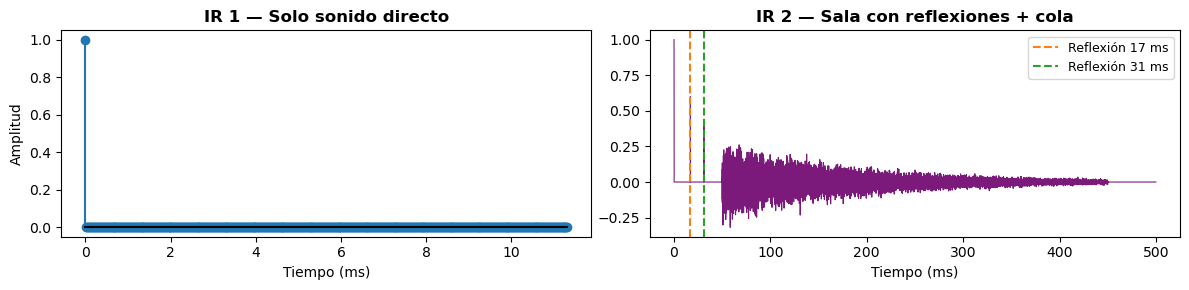

In [7]:
# Visualizar las dos IRs
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

t_dry  = np.arange(len(ir_dry))  / FS * 1000
t_room = np.arange(len(ir_room)) / FS * 1000

axes[0].stem(t_dry[:500], ir_dry[:500], linefmt='C0-', markerfmt='C0o', basefmt='k-')
axes[0].set_title('IR 1 — Solo sonido directo', fontweight='bold')
axes[0].set_xlabel('Tiempo (ms)'); axes[0].set_ylabel('Amplitud')

axes[1].plot(t_room, ir_room, color='#7b1a7a', linewidth=0.8)
axes[1].axvline(17, color='C1', linestyle='--', label='Reflexión 17 ms')
axes[1].axvline(31, color='C2', linestyle='--', label='Reflexión 31 ms')
axes[1].set_title('IR 2 — Sala con reflexiones + cola', fontweight='bold')
axes[1].set_xlabel('Tiempo (ms)'); axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('desafio02_irs.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Parte 3 — Diseña tu propia IR 🏗️

**El problema:**

> Una habitación tiene **una sola pared reflectante a 3 metros**.
> La velocidad del sonido es **343 m/s**.
> El sonido viaja 3 m de ida y 3 m de vuelta = **6 metros en total**.

<div style='background:#F4F4F4;border-left:5px solid #1a6e3c;padding:14px 20px;border-radius:6px;font-family:monospace;font-size:14px;margin:12px 0'>
delay_segundos = 6 m / 343 m/s = ??? s<br>
delay_muestras = delay_segundos × 44100 = ??? muestras
</div>

**❓ Calculen el delay en papel antes de correr la celda.**

In [8]:
# Calcular el delay
distancia_total = 6.0           # metros (ida y vuelta)
velocidad_sonido = 343.0        # m/s

delay_s       = distancia_total / velocidad_sonido
delay_samples = int(delay_s * FS)

print(f'Delay:  {delay_s*1000:.1f} ms  =  {delay_samples} muestras')

Delay:  17.5 ms  =  771 muestras


  ✓  desafio02_my_ir.wav  (262.2 KB)


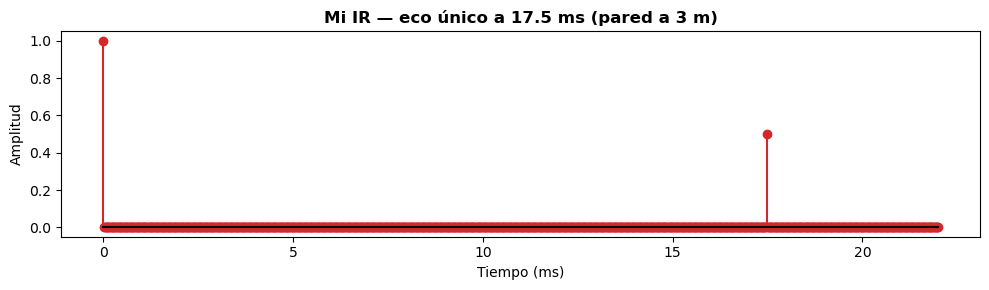


¿Se escucha el eco único en desafio02_my_ir.wav?


In [9]:
# Construir la IR y escuchar
my_ir = np.zeros(delay_samples + 200)
my_ir[0]             = 1.0   # sonido directo
my_ir[delay_samples] = 0.5   # reflexión única

resultado = fftconvolve(dry_voice, my_ir)
save_wav('desafio02_my_ir.wav', resultado)

# Visualizar
fig, ax = plt.subplots(figsize=(10, 3))
t_ir = np.arange(len(my_ir)) / FS * 1000
ax.stem(t_ir, my_ir, linefmt='C3-', markerfmt='C3o', basefmt='k-')
ax.set_title(f'Mi IR — eco único a {delay_s*1000:.1f} ms (pared a 3 m)', fontweight='bold')
ax.set_xlabel('Tiempo (ms)'); ax.set_ylabel('Amplitud')
plt.tight_layout(); plt.show()

print('\n¿Se escucha el eco único en desafio02_my_ir.wav?')

<div style='background:#E8EFF6;border-left:5px solid #004787;padding:16px 22px;border-radius:6px;margin-top:8px'>

**Para seguir explorando — modifica los valores y vuelve a correr:**

- ¿Qué pasa si la pared está a **30 metros**?
- ¿Y si hay **tres paredes** a 3, 7 y 12 metros?
- ¿Qué pasa si el coeficiente de reflexión es **0.99** en vez de 0.5?

</div>

---
<div style='background:#1C1C1C;color:#C8D8EA;padding:14px 22px;border-radius:8px;font-size:13px;text-align:center'>
Desafío Relámpago · Sesión 02 · Análisis y Síntesis de Señales Musicales · PUC Chile · 2026
</div>